In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2012-01-01'
max_date        = '2023-12-31'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0,
    prediction_mode     ='regression',
    temporal_frequency  ='m',
    weekly_time_index   = False ,
    daily_time_index    = False,
    monthly_time_index  = True
    )    

nuts_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

# bd = BaseLineDataLoaderManager(data_orchestrator)
# sd = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
# gl = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

AirpConfig loaded succesfully ✓
AirpOrchestrator loaded succesfully ✓


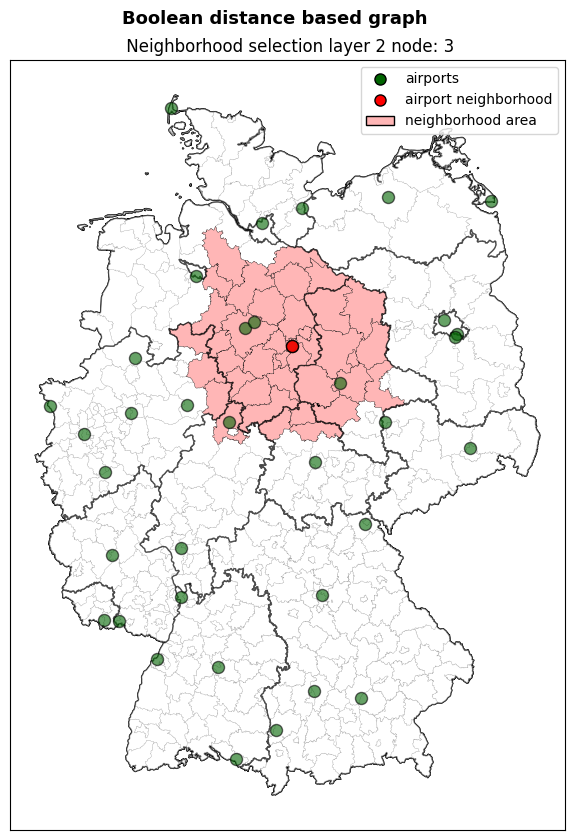

In [ ]:
from src.dataloading.airp import AirpConfig, AirpOrchestrator
from src.graphconstruction.airportgraph import AirportGraphOrchestrator, AirportGraphViewer

airpconfig                  = AirpConfig(nuts_orchestrator)
airp_orchestrator           = AirpOrchestrator(airpconfig, nuts_orchestrator).build_orchestration()

graph_orchestrator          = AirportGraphOrchestrator(airp_orchestrator)
graph_structure             = graph_orchestrator.generate_graphstructure('distance',  decay = 'boolean')
graph_previewer             = AirportGraphViewer(graph_orchestrator, airp_orchestrator.data_context,graph_structure)

figure                      = (graph_previewer
                               .view(graphname = 'a', node_layer2=3)
                               .ticks.change_xticks([])
                               .ticks.change_yticks([])
                               .labels.change_suptitle('Boolean distance based graph', fontweight='bold', fontsize = 13)
                               .labels.set_suptitle_y(0.93)
                               )

figure.show()
graph_orchestrator.save_graphstructures(graph_structure, 'boolean_distance')

## Graph structure

In [ ]:
from src.utils.textformatting import align
from src.graphconstruction.airportgraph.graphstructure import GraphStructure, GraphStructureError


import torch 
from dataclasses import dataclass
from typing import List



@dataclass
class NutsLayerGraphData:
    """
    Data for graph layer L1

    Parameters
    ----------
    x: torch.Tensor 
    edge_index: torch.Tensor 
    edge_weight: torch.Tensor 
    y: torch.Tensor
    """

    x:          torch.Tensor
    edge_index: torch.Tensor
    edge_weight:torch.Tensor
    y:          torch.Tensor
        
    def __post_init__(self):
        # validate input
        l, num_edges                        = self.edge_index.shape
        num_nodes_x, num_feat_x, num_seq_x  = self.x.shape
        num_nodes_y, num_horizon_y          = self.y.shape
        
        if l != 2:
            raise GraphStructureError('NutsLayerGraphData edge_index is expected to be of length 2')
        
        if num_edges != len(self.edge_weight):
            raise GraphStructureError(f'NutsLayerGraphData edge_index contains {num_edges} edges while edge_weight {len(self.edge_weight)} edges')     

        if num_nodes_x != num_nodes_y:
            raise GraphStructureError(f'NutsLayerGraphData x contains {num_nodes_x} nodes while y {num_nodes_y} nodes') 

        # TODO: Validate num_feat_x, num_seq_x, num_horizon_y against config                       
        
    def __repr__(self):
        cls = self.__class__.__name__
        info = (
            f"x={tuple(self.x.shape)}, "
            f"y={tuple(self.y.shape)}, "
            f"edge_index={tuple(self.edge_index.shape)}, "
            f"edge_weight={tuple(self.edge_weight.shape)}"
        )
        return f"{cls}({info})"
    
@dataclass
class AirportLayerGraphData:
    """
    Data for graph layer L2

    Parameters
    ----------
    x: torch.Tensor 
    edge_index: torch.Tensor 
    edge_weight: torch.Tensor
    """
    x:          torch.Tensor
    edge_index: torch.Tensor
    edge_weight:torch.Tensor
        
    def __repr__(self):
        cls = self.__class__.__name__
        info = (
            f"x={tuple(self.x.shape)}, "
            f"edge_index={tuple(self.edge_index.shape)}, "
            f"edge_weight={tuple(self.edge_weight.shape)}"
        )
        return f"{cls}({info})"    

    def __post_init__(self):
        # validate input
        l, num_edges                        = self.edge_index.shape
        num_nodes_x, num_feat_x, num_seq_x  = self.x.shape
        
        if l != 2:
            raise GraphStructureError('AirportLayerGraphData edge_index is expected to be of length 2')
        
        if num_edges != len(self.edge_weight):
            raise GraphStructureError(f'AirportLayerGraphData edge_index contains {num_edges} edges while edge_weight {len(self.edge_weight)} edges')     

        # TODO: Validate num_nodes_x, num_feat_x, num_seq_x, num_horizon_y against config of airport data
                
class NestedGraphData:
    """
    Data for graph layers L1 and L2 combined

    Parameters
    ----------
    nuts_layer:    NutsLayerGraphData
    airport_layer: AirportLayerGraphData
    """
    def __init__(self, 
                 nuts_layer:    NutsLayerGraphData, 
                 airport_layer: AirportLayerGraphData):
        
        # NUTS layer: L1
        self.x_l1           = nuts_layer.x 
        self.edge_index_l1  = nuts_layer.edge_index
        self.edge_weight_l1 = nuts_layer.edge_weight

        # Airport layer: L2
        self.x_l2           = airport_layer.x
        self.edge_index_l2  = airport_layer.edge_index 
        self.edge_weight_l2 = airport_layer.edge_weight 

        # Targets -> for L1
        self.y              = nuts_layer.y

        # based on airport graph
        num_airports      = self.edge_index_l2[0].max().item() + 1
        num_nodes_l2      = self.edge_index_l2[1].max().item() + 1       
        num_nodes_l1      = max(self.edge_index_l1[0].max().item(),self.edge_index_l1[1].max().item()) + 1

        if num_nodes_l1 != num_nodes_l2:
            raise GraphStructureError(f'num nodes found in L2: {num_nodes_l2} and in L1: {num_nodes_l1}')

    def to(self, device):
        """Move all tensors to device"""
        device = torch.device(device)   # Normalize device string/object
  
        self.x_l1           = self.x_l1.to(device)
        self.edge_index_l1  = self.edge_index_l1.to(device)
        self.edge_weight_l1 =self.edge_weight_l1.to(device)

        self.x_l2           = self.x_l2.to(device)  
        self.edge_index_l2  = self.edge_index_l2.to(device)
        self.edge_weight_l2 = self.edge_weight_l2.to(device)        

        self.y              = self.y.to(device)
        return self

    def cpu(self):
        """Convenience method to move to CPU"""
        return self.to('cpu')

    def cuda(self, device=None):
        """Convenience method to move to CUDA"""
        if device is None:
            return self.to('cuda')
        return self.to(f'cuda:{device}')

    @property
    def device(self):
        """Get current device of the data (from first layer's x tensor)"""
        return self.x_l1.device

    def __repr__(self):
        lines = f'<{self.__class__.__name__}(L1, L2)>'
        return lines

    def __str__(self):
        indent = 4
        keys   = ['edge_weight', 'edge_index']
        width  = max(len(k) for k in keys) + 1
        # Build output
        lines = [f'<{self.__class__.__name__}(']

        first_header = align('L1',"NUTS", 1)
        second_header = align('L2',"Airports", 1)

        lines.append(first_header)
        lines.append(" "*indent+"_"*len(first_header))
        lines.append(align('x', tuple(self.x_l1.shape), width))
        lines.append(align('edge_index', tuple(self.edge_index_l1.shape), width))        
        lines.append(align('edge_weight', tuple(self.edge_weight_l1.shape), width)) 
        lines.append('')         
        lines.append(second_header)     
        lines.append(" "*indent+"_"*len(second_header))          
        lines.append(align('x', tuple(self.x_l2.shape), width))
        lines.append(align('edge_index', tuple(self.edge_index_l2.shape), width))        
        lines.append(align('edge_weight', tuple(self.edge_weight_l2.shape), width))         
        lines.append(')>')
        
        return '\n'.join(lines)
    
class GraphDataSet:
    """
    A list of Data objects, for now limited to NestedGraphData objects

    Parameters
    ----------
    data_list: List[NestedGraphData]
    """    
    def __init__(self, data_list: List[NestedGraphData]):
        self.data_list  = data_list
        self._data_class= data_list[0].__class__.__name__

    def __iter__(self):
        return iter(self.data_list)
    
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx: int):
        return self.data_list[idx]                   

    def __repr__(self):
        return self.__str__()

    def __str__(self) -> str:
        keys   = ['datapoints','dataclass']
        width  = max(len(k) for k in keys) + 1
        # Build output
        lines = [f'<{self.__class__.__name__}(\n']
        lines.append(align('datapoints',self.__len__(),width,newline=True))
        lines.append(align('dataclass',self._data_class, width))
        lines.append(')>')
        
        return ''.join(lines)

In [ ]:
import torch
import pandas as pd
import numpy as np 
import os
from typing import List, Tuple, Optional, Union, Literal, TYPE_CHECKING
from dataclasses import dataclass

from tqdm import tqdm
from src.utils.textformatting import error_emoji

if TYPE_CHECKING:
    import DataOrchestrator, AirpOrchestrator


@dataclass
class GraphDataCollection:
    """ 
    Stores all DataSets for deep-graph-dataloaders

    Parameters
    ----------
    train: 'GraphDataSet

    val: 'GraphDataSet

    test: 'GraphDataSet

    main: 'GraphDataSet

    Downstream
    --------
    """
    train:              'GraphDataSet'
    val:                'GraphDataSet'   
    test:               'GraphDataSet'
    main:               'GraphDataSet'

    def __repr__(self):
        return (f"<GraphDataLoaderCollection(train, val, test, main)>") 

class NestedGraphDataLoaderManager:
    """
    """
    def __init__(self, 
                 epidata_orchestrator: DataOrchestrator,
                 airpdata_orchestrator: AirpOrchestrator):
        
        self.epidata_orchestrator       = epidata_orchestrator
        self.airpdata_orchestrator      = airpdata_orchestrator
        
        self.nuts_graph_mode: Optional[Literal['static','dynamic']] = None
            
    def retrieve_static_graph_L1(self, graphname: str, graphdirectory: str = 'data/graphs') -> 'NestedGraphDataLoaderManager':
        """
        load a graph object.

        Parameters
        ----------
        graphname: str
            The name of the file. Should correspond to the filename: f'{graphdirectory}/{graphname}/_edge_index.pt' and edge_weight.
            
        graphdirectory: str = 'data/graphs'
        """
    
        graphpath  = os.path.join(graphdirectory, self.epidata_orchestrator.config.nuts_level, graphname, graphname)
        
        try:
            i           = torch.load(graphpath + '_edge_index.pt', weights_only = False)
            w           = torch.load(graphpath + '_edge_weight.pt', weights_only = False)
            graph       = GraphStructure(i,w)
           
        except Exception as e:
            raise RuntimeError(f'graph by the name of {graphname} not found')
    
        self._validate_graphstructure(i, w, graphname)

        self.graph      = graph
        self._graphmode = 'static'
        
        return self
    
    def retrieve_static_graph_L2(self, graphane)
   
    # def construct_dataloaders(self):
    #     """
    #     creates the actual dataloaders
    #     """
    #     X,y,t                             = self._construct_Xy(self.dataorchestrator.data_final.data)
    #     main_dataloader                   = self._construct_main_dataloader(X = X, y = y, t= t)
    #     self.dataloader_collection        = self._split_dataloader(main_dataloader = main_dataloader)
    #     return self     
    
    # def _construct_Xy(self, 
    #                   df: pd.DataFrame) -> Tuple[torch.Tensor, torch.Tensor, List[Union[pd.Timestamp, str]]]:
    #     """
    #     constructs torch.tensor objects from df, which should be the dataorchestrator's final data object.
        
    #     Returns:
    #     -------
    #     X: torch.Tensor
    #         Input data of shape [num_timestamps, num_nodes, num_features]
    #     y: torch.Tensor
    #         Target data of shape [num_timestamps, num_nodes, horizon_size]          
    #     """

    #     dfc                 = df.copy()
    #     feature_arrays      = []
    #     target_arrays       = []
    #     t                   = dfc['timestamp'].unique().tolist()

    #     feature_cols = self.column_registration.get_by_type('feature')
    #     split_cols   = self.column_registration.get_by_type('split')
    #     target_cols  = self.column_registration.get_by_type('target')          

    #     time_splits         = dfc[['timestamp'] + split_cols].drop_duplicates().reset_index(drop = True)
    #     self.time_splits    = time_splits

    #     for feat in feature_cols:
    #         dtype = dfc[feat].dtype
    #         # Pivot from long to wide: rows=time, columns=nodes, values=feature
    #         pivoted = dfc.pivot(index=['timestamp'], columns='node', values=feat).reset_index(drop = True)

    #         # set missing nodes to zero
    #         # pivoted = pivoted.reindex(index=timestamps, columns=node_ids)

    #         # # convert to numeric
    #         pivoted = pivoted.apply(pd.to_numeric, errors='coerce')

    #         # # Convert to numpy float array, replace NaNs with 0
    #         arr = pivoted.values
    #         if str(dtype).startswith('int'):
    #             arr = arr.astype(np.int32)
    #         else:
    #             arr = arr.astype(np.float32)             # force float32 dtype

    #         feature_arrays.append(arr)

    #     X_np = np.stack(feature_arrays, axis=-1)

    #     for target in target_cols:
    #         for dfc_col in dfc.columns:
                
    #             if target in dfc_col and dfc_col not in feature_cols:
    #                 dtype = dfc[dfc_col].dtype
    #                 # Pivot from long to wide: rows=time, columns=nodes, values=feature
    #                 pivoted = dfc.pivot(index=['timestamp'], columns='node', values=dfc_col).reset_index(drop = True)

    #                 # set missing nodes to zero
    #                 # pivoted = pivoted.reindex(index=timestamps, columns=node_ids)

    #                 # # convert to numeric
    #                 pivoted = pivoted.apply(pd.to_numeric, errors='coerce')
                    
    #                 # # Convert to numpy float array, replace NaNs with 0
    #                 arr = pivoted.values
    #                 if str(dtype).startswith('int'):
    #                     arr = arr.astype(np.int32)
    #                 else:
    #                     arr = arr.astype(np.float32)   
    #                 target_arrays.append(arr)

    #     # Process target column using same approach
    #     y_np = np.stack(target_arrays, axis=-1)

    #     X = torch.tensor(X_np, dtype=torch.float)
    #     y = torch.tensor(y_np,dtype=torch.float)
    #     return X, y, t

    # def _construct_main_dataloader(self, 
    #                                X: torch.Tensor,
    #                                y: torch.Tensor,
    #                                t: List[str]) -> GraphDataLoader:
    #     """
    #     construct main dataloader based on X, y, edge_index and edge_weight

    #     Returns
    #     -------
    #     GraphDataLoader
    #     """


    #     dataset = []
    #     T       = X.shape[0]  # Total number of timesteps

    #     # Calculate maximum valid start position
    #     # Need: start + periods + prediction_horizon - 1 < T
    #     max_start       = T - self.dataorchestrator.config.horizon_leadtime - (self.dataorchestrator.config.horizon_size - 1) - (self.dataorchestrator.config.sequence_length - 1)
    #     self.max_start  = max_start

    #     if max_start <= 0:
    #         raise ValueError(f"Not enough data: T={T}, periods={self.dataorchestrator.config.sequence_length}"
    #                         f"Need at least {self.dataorchestrator.config.sequence_length} timesteps.")

    #     for t_idx, start in enumerate(range(max_start)):
    #         # Input window: periods consecutive timesteps
    #         x_seq = X[start : start + self.dataorchestrator.config.sequence_length]  # shape [periods, nodes, features]
    #         y_seq = y[start + self.dataorchestrator.config.sequence_length - 1]

    #         if self._graphmode == 'dynamic':
    #             year            = t[t_idx].year
    #             graphstructure_t = self.graph.get_snapshot(str(year))

    #         else:
    #             graphstructure_t = self.graph
            
    #         data = GraphData(
    #             x = x_seq.clone().detach().float().permute(1, 2, 0),  # (nodes, features, periods)
    #             y = y_seq.clone().detach().float(),                   # (nodes, horizon)
    #             edge_index = graphstructure_t.edge_index,
    #             edge_weight =graphstructure_t.edge_weight
    #         )
    #         dataset.append(data)

    #     return GraphDataLoader(dataset)

    # def _split_dataloader(self, 
    #                       main_dataloader: GraphDataLoader) -> GraphDataLoaderCollection:
    #     """
    #     Splits main dataloader into those for train/val/test
    #     """        

    #     train_idx = list(self.time_splits[self.time_splits['train']].index)
    #     val_idx   = list(self.time_splits[self.time_splits['val']].index)
    #     test_idx  = list(self.time_splits[self.time_splits['test']].index)

    #     dataloader_train = GraphDataLoader([main_dataloader[tt] for tt in train_idx])
    #     dataloader_val   = GraphDataLoader([main_dataloader[tt] for tt in val_idx])
    #     dataloader_test  = GraphDataLoader([main_dataloader[tt] for tt in test_idx if tt < self.max_start])        
        
    #     return GraphDataLoaderCollection(
    #         train = dataloader_train,
    #         val   = dataloader_val,
    #         test  = dataloader_test,
    #         main  = main_dataloader
    #     )

    def _validate_graphstructure(self, edge_index: torch.Tensor, edge_weight: torch.Tensor, structure_name: str):
        """validates edge index and edge weight; num_nodes is compared to each other and to data_orchestrator"""
        num_nodes_graph = len(edge_index.unique())
        
        if len(edge_index[0]) != len(edge_weight):
            raise GraphStructureError(f'{error_emoji} {structure_name}: edge_index and edge_weight have a different length')
        
        if num_nodes_graph != self.epidata_orchestrator.data_context.num_nodes:
            raise GraphStructureError(f'{error_emoji} {structure_name}: has {num_nodes_graph} nodes while data_orchestrator has {self.epidata_orchestrator.data_context.num_nodes} nodes')
        
    def __repr__(self) -> str:

        representation = f'<GraphDataLoaderManager(dataloaders at .dataloader_collection)>'          
        return representation

In [ ]:
xyz = NestedGraphDataLoaderManager(nuts_orchestrator, airp_orchestrator)
xyz.retrieve_static_graph(graphname ='identity_graph')

<GraphDataLoaderManager(dataloaders at .dataloader_collection)>